In [1]:
import numpy as np
import pandas as pd 
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd


os.chdir('..')  # Go up to project root
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/.DS_Store
./kaggle/input/cho-oyu.csv
./kaggle/input/everest_20-25.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/makalu.csv


In [2]:
everest20_25 = pd.read_csv('./kaggle/input/everest_20-25.csv')

In [3]:
# Format dates
everest20_25['Date'] = pd.to_datetime(everest20_25['Date'], format='mixed', errors='coerce')
everest20_25['year'] = everest20_25['Date'].dt.year
everest20_25['month'] = everest20_25['Date'].dt.month

# Check if any dates failed to parse
print(f"Missing dates: {everest20_25['Date'].isna().sum()}")

# Deaths per year
everest20_25['year'].value_counts().sort_index()

Missing dates: 0


year
2020    86
2021    93
2022    92
2023    86
2024    73
2025    70
Name: count, dtype: int64

In [4]:
# Format expedition type
everest20_25['expedition_type'] = everest20_25['Expedition_Company'].apply(
    lambda x: 'Independent/Private' if pd.isna(x) or 'Independent' in str(x) or 'Private' in str(x) 
    else 'Commercial Company'
)

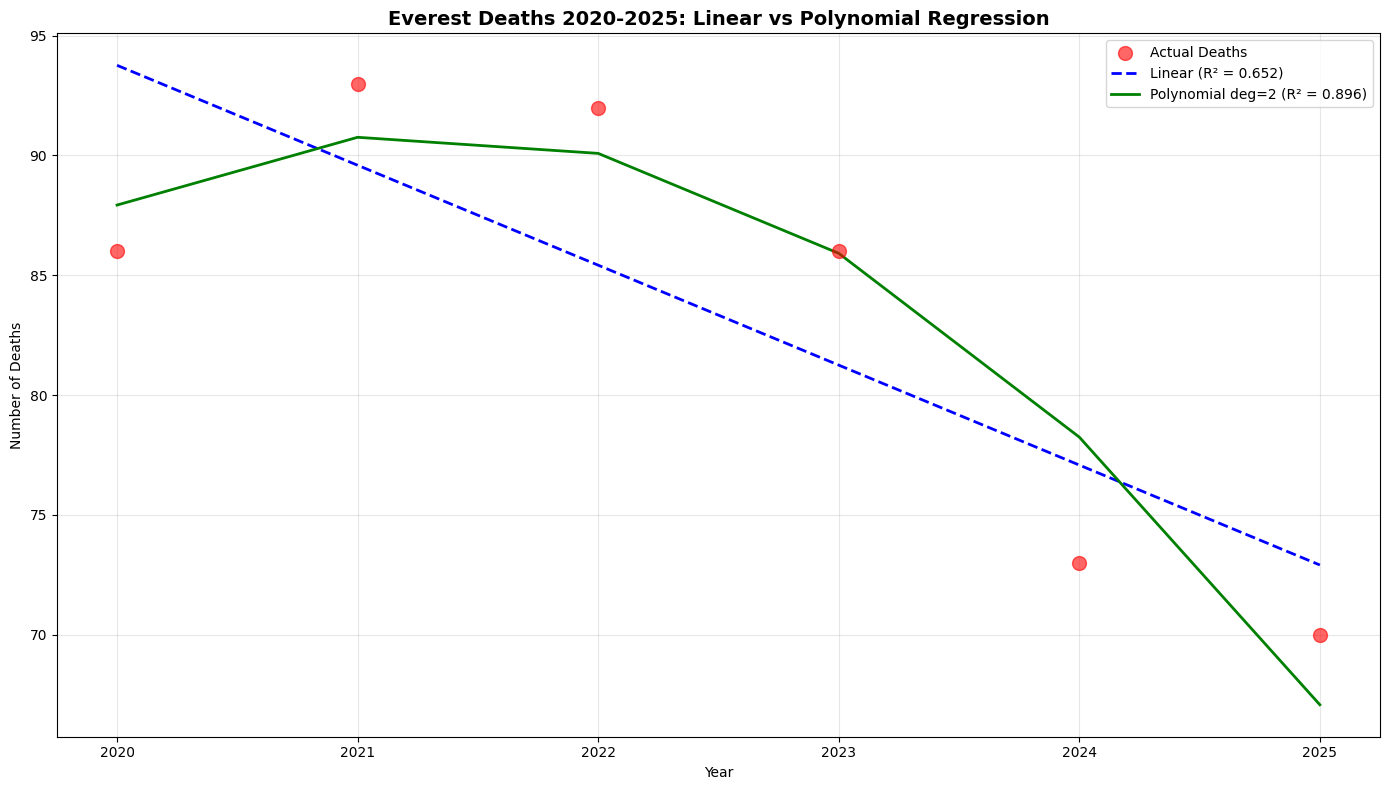

EVEREST 2020-2025 REGRESSION ANALYSIS
Linear Regression:      R² = 0.6516 (65.16%)
Polynomial (degree 2):  R² = 0.8963 (89.63%)
Slope: -4.17 deaths/year
P-value: 0.0522
✗ Not statistically significant (small sample size)


In [8]:
# 1. Deaths over time (2020-2025)
deaths_by_year = everest20_25['year'].value_counts().sort_index()
years = deaths_by_year.index.values
deaths = deaths_by_year.values

# Linear regression
linear_model = stats.linregress(years, deaths)
linear_fit = linear_model.slope * years + linear_model.intercept
linear_r2 = linear_model.rvalue ** 2

# Polynomial regression (degree 2)
poly_coeffs_2 = np.polyfit(years, deaths, deg=2)
poly_model_2 = np.poly1d(poly_coeffs_2)
poly_fit_2 = poly_model_2(years)

# Calculate R² for polynomial
ss_res_2 = np.sum((deaths - poly_fit_2) ** 2)
ss_tot = np.sum((deaths - np.mean(deaths)) ** 2)
poly_r2_2 = 1 - (ss_res_2 / ss_tot)

# Visualize
plt.figure(figsize=(14, 8))
plt.scatter(years, deaths, color='red', s=100, alpha=0.6, label='Actual Deaths', zorder=3)
plt.plot(years, linear_fit, '--', color='blue', linewidth=2, 
         label=f'Linear (R² = {linear_r2:.3f})')
plt.plot(years, poly_fit_2, '-', color='green', linewidth=2, 
         label=f'Polynomial deg=2 (R² = {poly_r2_2:.3f})')

plt.title('Everest Deaths 2020-2025: Linear vs Polynomial Regression', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_2020_2025_regression.png', dpi=300, bbox_inches='tight')
plt.show()

print("EVEREST 2020-2025 REGRESSION ANALYSIS")
print("=" * 60)
print(f"Linear Regression:      R² = {linear_r2:.4f} ({linear_r2*100:.2f}%)")
print(f"Polynomial (degree 2):  R² = {poly_r2_2:.4f} ({poly_r2_2*100:.2f}%)")
print(f"Slope: {linear_model.slope:.2f} deaths/year")
print(f"P-value: {linear_model.pvalue:.4f}")
if linear_model.pvalue < 0.05:
    print("✓ Statistically significant trend")
else:
    print("✗ Not statistically significant (small sample size)")


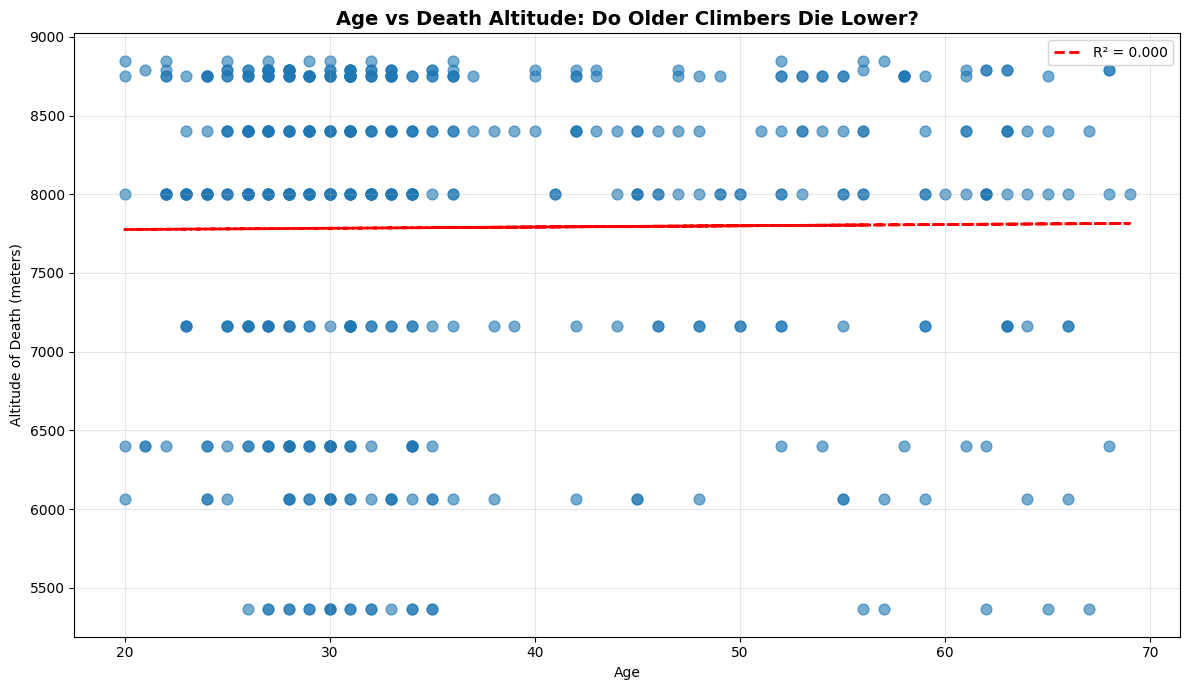


AGE VS ALTITUDE REGRESSION
R² = 0.0001
Slope: 0.79 meters per year of age
P-value: 0.8268
✗ No significant relationship between age and death altitude


In [9]:
# 2. Age vs Altitude (Do older climbers die at lower altitudes?)
age_alt_clean = everest20_25[['Age', 'Altitude_meters']].dropna()
ages = age_alt_clean['Age'].values
altitudes = age_alt_clean['Altitude_meters'].values

age_alt_model = stats.linregress(ages, altitudes)
age_alt_fit = age_alt_model.slope * ages + age_alt_model.intercept

plt.figure(figsize=(12, 7))
plt.scatter(ages, altitudes, alpha=0.6, s=60)
plt.plot(ages, age_alt_fit, 'r--', linewidth=2, 
         label=f'R² = {age_alt_model.rvalue**2:.3f}')
plt.xlabel('Age')
plt.ylabel('Altitude of Death (meters)')
plt.title('Age vs Death Altitude: Do Older Climbers Die Lower?', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/everest_age_vs_altitude.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAGE VS ALTITUDE REGRESSION")
print("=" * 60)
print(f"R² = {age_alt_model.rvalue**2:.4f}")
print(f"Slope: {age_alt_model.slope:.2f} meters per year of age")
print(f"P-value: {age_alt_model.pvalue:.4f}")
if age_alt_model.pvalue < 0.05:
    if age_alt_model.slope < 0:
        print("✓ Older climbers die at significantly LOWER altitudes")
    else:
        print("✓ Older climbers die at significantly HIGHER altitudes")
else:
    print("✗ No significant relationship between age and death altitude")

In [13]:
# Machine Learning Model
# Prepare data - predict Cause of Death
print("\nPREPARING DATA FOR MACHINE LEARNING")
print("=" * 80)

# Create a clean dataset with no missing values in key columns
ml_data = everest20_25[['Age', 'Gender', 'Altitude_meters', 'Route', 'Season', 
                        'Weather_Conditions', 'Experience_Level', 'expedition_type', 
                        'Cause_of_Death']].copy()

# Drop rows with missing values
ml_data = ml_data.dropna()

print(f"Dataset size after removing missing values: {len(ml_data)} records")
print(f"Predicting: Cause of Death")
print(f"Using features: Age, Gender, Altitude, Route, Season, Weather, Experience, Expedition Type")

# Encode categorical variables
encoders = {}
categorical_cols = ['Gender', 'Route', 'Season', 'Weather_Conditions', 'Experience_Level', 'expedition_type']

for col in categorical_cols:
    encoders[col] = LabelEncoder()
    ml_data[f'{col}_encoded'] = encoders[col].fit_transform(ml_data[col])

# Prepare X and y
feature_cols = ['Age', 'Altitude_meters', 'Gender_encoded', 'Route_encoded', 
                'Season_encoded', 'Weather_Conditions_encoded', 
                'Experience_Level_encoded', 'expedition_type_encoded']
X = ml_data[feature_cols]
y = ml_data['Cause_of_Death']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"\nTraining set: {len(X_train)} records")
print(f"Test set: {len(X_test)} records")

# Dictionary of models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Train and evaluate
results = []

print("\nMACHINE LEARNING MODEL COMPARISON")
print("=" * 80)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    # Cross-validation
    try:
        cv_scores = cross_val_score(model, X, y, cv=5)
        cv_mean = cv_scores.mean()
    except:
        cv_mean = 0
    
    results.append({
        'Model': name,
        'Train Accuracy': train_score,
        'Test Accuracy': test_score,
        'CV Accuracy': cv_mean
    })
    
    print(f"{name:25s} | Train: {train_score:.2%} | Test: {test_score:.2%} | CV: {cv_mean:.2%}")

print("=" * 80)

# Results DataFrame
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)

print("\nBEST MODELS (sorted by Test Accuracy):")
print(results_df.to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n🏆 WINNER: {best_model_name} with {results_df.iloc[0]['Test Accuracy']:.2%} test accuracy")

# Feature importance (if applicable)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_names = ['Age', 'Altitude', 'Gender', 'Route', 'Season', 
                     'Weather', 'Experience', 'Expedition Type']
    importances = best_model.feature_importances_
    
    print(f"\nFeature Importance for {best_model_name}:")
    print("-" * 60)
    feature_importance = sorted(zip(feature_names, importances), 
                                key=lambda x: x[1], reverse=True)
    for name, importance in feature_importance:
        print(f"  {name:20s}: {importance:.4f} ({importance*100:.1f}%)")
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    features, values = zip(*feature_importance)
    plt.barh(features, values, color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('images/everest_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


PREPARING DATA FOR MACHINE LEARNING
Dataset size after removing missing values: 500 records
Predicting: Cause of Death
Using features: Age, Gender, Altitude, Route, Season, Weather, Experience, Expedition Type

Training set: 375 records
Test set: 125 records

MACHINE LEARNING MODEL COMPARISON
Random Forest             | Train: 99.73% | Test: 17.60% | CV: 21.00%
Gradient Boosting         | Train: 97.60% | Test: 12.80% | CV: 16.40%
Decision Tree             | Train: 99.73% | Test: 12.00% | CV: 12.40%
K-Nearest Neighbors       | Train: 40.80% | Test: 20.00% | CV: 20.80%
Naive Bayes               | Train: 15.73% | Test: 14.40% | CV: 11.80%


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

Logistic Regression       | Train: 27.20% | Test: 23.20% | CV: 23.20%

BEST MODELS (sorted by Test Accuracy):
              Model  Train Accuracy  Test Accuracy  CV Accuracy
Logistic Regression        0.272000          0.232        0.232
K-Nearest Neighbors        0.408000          0.200        0.208
      Random Forest        0.997333          0.176        0.210
        Naive Bayes        0.157333          0.144        0.118
  Gradient Boosting        0.976000          0.128        0.164
      Decision Tree        0.997333          0.120        0.124

🏆 WINNER: Logistic Regression with 23.20% test accuracy


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

In [14]:
# Can we predict the altitude where someone will die based on their characteristics?
print("\n" + "=" * 80)
print("PREDICTING DEATH ALTITUDE (Regression Problem)")
print("=" * 80)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare data
altitude_data = everest20_25[['Age', 'Gender', 'Route', 'Season', 
                               'Weather_Conditions', 'Experience_Level', 
                               'expedition_type', 'Altitude_meters']].copy()
altitude_data = altitude_data.dropna()

# Encode
for col in categorical_cols:
    if col in altitude_data.columns:
        altitude_data[f'{col}_encoded'] = encoders[col].fit_transform(altitude_data[col])

X_alt = altitude_data[['Age', 'Gender_encoded', 'Route_encoded', 'Season_encoded',
                       'Weather_Conditions_encoded', 'Experience_Level_encoded', 
                       'expedition_type_encoded']]
y_alt = altitude_data['Altitude_meters']

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y_alt, test_size=0.25, random_state=42)

# Models for regression
regression_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Linear Regression': LinearRegression()
}

altitude_results = []

for name, model in regression_models.items():
    model.fit(X_train_alt, y_train_alt)
    
    train_pred = model.predict(X_train_alt)
    test_pred = model.predict(X_test_alt)
    
    train_r2 = r2_score(y_train_alt, train_pred)
    test_r2 = r2_score(y_test_alt, test_pred)
    test_mae = mean_absolute_error(y_test_alt, test_pred)
    
    altitude_results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'MAE (meters)': test_mae
    })
    
    print(f"{name:20s} | Train R²: {train_r2:.3f} | Test R²: {test_r2:.3f} | MAE: {test_mae:.0f}m")

altitude_results_df = pd.DataFrame(altitude_results).sort_values('Test R²', ascending=False)
print("\n" + altitude_results_df.to_string(index=False))


PREDICTING DEATH ALTITUDE (Regression Problem)
Random Forest        | Train R²: 0.844 | Test R²: -0.220 | MAE: 932m
Gradient Boosting    | Train R²: 0.458 | Test R²: -0.192 | MAE: 910m
Decision Tree        | Train R²: 1.000 | Test R²: -0.934 | MAE: 1023m
Linear Regression    | Train R²: 0.011 | Test R²: -0.003 | MAE: 837m

            Model  Train R²   Test R²  MAE (meters)
Linear Regression  0.010911 -0.002997    837.466905
Gradient Boosting  0.457558 -0.191518    909.800682
    Random Forest  0.843602 -0.219856    932.236427
    Decision Tree  0.999795 -0.933956   1023.080000
